Nome: Brendon Erick Euzébio Rus Peres

RA: 256130

Curso: Mestrado em Engenharia Elétrica



# Ex05 - Classificação de imagens usando rede neural convolucional (CNN)

O objetivo principal deste notebook é ilustrar e praticar o uso de redes neurais convolucionais (CNNs) para tarefas de classificação de imagens. Em relação às redes neurais convencionais, as CNNs geralmente apresentam a vantagem de possuir menos parâmetros a serem aprendidos. Além disso, as CNNs são particularmente adequadas para trabalhar com imagens devido à sua arquitetura projetada para lidar com dados espaciais de forma eficiente.

Tomaremos como base a biblioteca PyTorch, que segue uma abordagem de programação orientada a objetos. Além dela, recomendamos o uso de outras bibliotecas relacionadas (como o PyTorch Lightning) que auxiliam e simplificam etapas do framework. Note que algumas destas bibliotecas podem não estar disponíveis por padrão no Colab ou sua máquina, sendo necessária sua instalação (como exemplificado na próxima célula de código).

Para mais informações sobre redes convolucionais, exemplos e boas práticas, recomendamos os materiais de apoio às aulas 5 e 6 disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub, vídeos e links de apoio. Em especial, o tutorial prático de classificação com CNN ([link](https://colab.research.google.com/drive/1uXLYbWwHT8cChAYmexV6QNUi5eI4ITod?usp=sharing)) pode ser de grande ajuda.

**Atenção!** Não se esqueça de utilizar a GPU do Colab (clique em "Ambiente de execução" e "Alterar o tipo de ambiente de execução", selecione a GPU).

In [1]:
# Instalando bibliotecas
!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics medmnist

In [2]:
# Importando as bibliotecas que serão utilizadas
import multiprocessing as mp
import os
import random
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchinfo
from medmnist import DermaMNIST
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import datasets, models
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

%load_ext tensorboard

In [3]:
torch.set_float32_matmul_precision('medium')

## Parte 1 - Exemplo de classificação com o MNIST

Exemplificaremos algumas das etapas do framework de classificação com CNN utilizando o conjunto de dados MNIST (Modified National Institute of Standards and Technology database), um grande conjunto de dados de dígitos manuscritos comumente usado na área de aprendizado de máquina. Ele consiste de 60.000 imagens de treinamento e 10.000 images de teste (que, no nosso exemplo, serão utilizadas para validação). As imagens do conjunto são de 28x28 pixels. Uma descrição completa do conjunto de dados pode ser encontrada [aqui](https://en.wikipedia.org/wiki/MNIST_database).

### Leitura dos dados

Idealmente, códigos para processar amostras de dados devem estar desacoplados do código do treinamento do modelo, facilitando sua legibilidade e modularidade. O PyTorch fornece duas primitivas de dados ([torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) e [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)) que facilitam a leitura, processamento e organização dos dados para entrada no modelo. Mais informações sobre Datasets e DataLoaders podem ser encontradas [aqui](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) e [aqui](https://blog.paperspace.com/dataloaders-abstractions-pytorch/).

In [4]:
# Carregando os dados utilizando torchvision.datasets e convertendo as imagens para tensores
training_data = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=True,
    transform=ToTensor()
)
val_data = datasets.MNIST(
    root="data_mnist",
    train=False,
    download=True,
    transform=ToTensor()
)

print(training_data)
print()
print(val_data)
print()
print("*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!")

Dataset MNIST
    Number of datapoints: 60000
    Root location: data_mnist
    Split: Train
    StandardTransform
Transform: ToTensor()

Dataset MNIST
    Number of datapoints: 10000
    Root location: data_mnist
    Split: Test
    StandardTransform
Transform: ToTensor()

*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!


**É sempre importante checar e visualizar os dados a cada etapa do framework de classificação, garantindo que eles estão de acordo com o esperado e evitando a propagação de erros.**

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 8
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


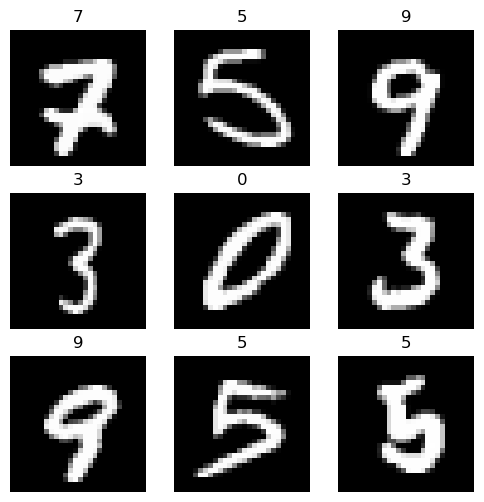

In [5]:
# Checando informações de uma amostra de treinamento
training_example = random.choice(training_data)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print('Shape da imagem:', training_example[0].shape)
print('Label:', training_example[1])
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(training_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 2
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


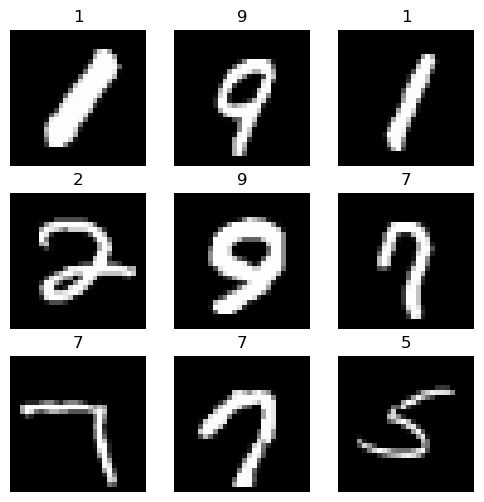

In [6]:
# Checando informações de uma amostra de validação
val_example = random.choice(val_data)
print(len(val_example))
print(type(val_example[0]), type(val_example[1]))
print('Shape da imagem:', val_example[0].shape)
print('Label:', val_example[1])
print('Maior valor de intensidade da imagem:', torch.max(val_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(val_example[0]))

# Visualizando algumas imagens e labels do conjunto de validação
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(val_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

### Exercício 1.1

Explique o processamento aplicado pela classe torchvision.transforms.ToTensor às imagens do conjunto. Explique também porque foi necessário utilizar o .squeeze() para visualizar as imagens e qual a sua função.

RESPOSTA:

O processamento aplicado pela torchvision.transforms.ToTensor serve pra converter uma imagem PIL ou np.ndarray (HxWxC) que possui valores [0,255] em um torch.FloatTensor no shape (CxHxW) possuindo valores [0.0,1.0].

E já o comando .squeeze, remove as dimensões que tiverem valor 1, pois carregam informações redundantes, porém tensors as usam para seu processamento. A bib matplotlib serve pra ela espera que imagens em tom de cinza estejam no formato HxW, e como o tensor dispõe o dado como (1xHxW), é preciso utilizar o .squeeze pra conseguir plotar.

### Hiperparâmetros

É interessante utilizar um dicionário de hiperparâmetros para organizar o código, evitar "números mágicos" e registrar as configurações de cada experimento realizado.

In [7]:
hparams = {"experiment_name": "Test_ResNet_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 100,  # size of batch
           "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 10,  # number of classes
           "nin": 1,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 8
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


### Data Module

A classe [pytorch_lightning.LightningDataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) pode ser utilizada para organizar os DataLoaders e os dados.

In [8]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = training_data
        self.val = val_data

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train,
                            batch_size=self.hparams.batch_size,
                            num_workers=self.hparams.nworkers,
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val,
                          batch_size=self.hparams.batch_size,
                          num_workers=self.hparams.nworkers,
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

**Novamente, checamos os dados obtidos através do DataModule.**

Shape do batch: torch.Size([100, 1, 28, 28])


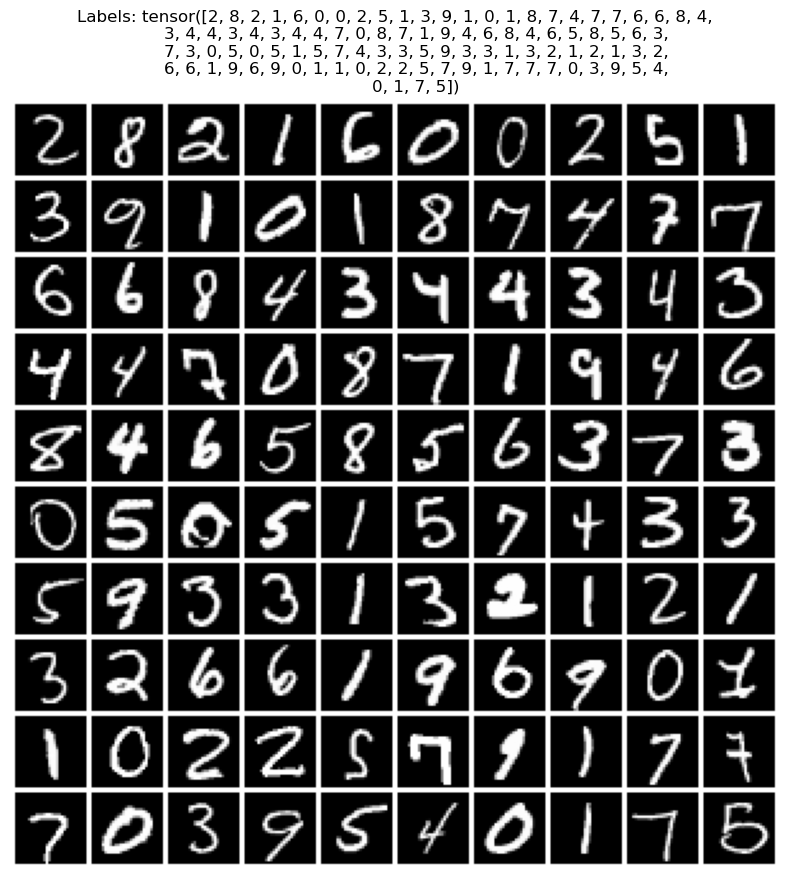

In [9]:
# DEBUG DATA MODULE
data_module = MNISTDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader()
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

### Definindo a CNN

No código abaixo, é criado um modelo baseado na [Resnet-18](https://pytorch.org/vision/master/models/generated/torchvision.models.resnet18.html). O mesmo será treinado **sem transfer learning** e com uma inicialização randômica dos pesos. Visualizamos também todas as camadas (layers) que compõem o modelo e seus parâmetros.

In [10]:
cnn_model = models.resnet18(weights=None)
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
cnn_model.conv1 = nn.Conv2d(hparams['nin'], 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])
print(cnn_model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Exercício 1.2

Para que serve cada camada da rede? Por que foi necessário modificar ligeiramente a rede (célula anterior) e que modificações foram realizadas?

RESPOSTA:

A camada Conv2d é pra extração de features, ela convoluciona sobre a imagem até aprender a extraírem algum padrão (isso a cada época). Similar ao que acontece com os kernels detectores de borda como o Prewitt e Sobel que também são 3x3.

A ReLU é uma função de ativação, ela serve para o modelo ser capaz de mapear funções (X -> Y) não-lineares.

A BatchNorm2d normaliza os dados que passam pela rede. Ele age sobre as entradas 4D (mini-batch das imagens 2d) para acelerar o treinamento e melhorar estabilidade. Isso normaliza os valores dos canais baseados no batch para se obter média igual a zero e variância unitária.

A MaxPool2d serve pra reduzir dimensões espaciais do dado. Por exemplo, a cada região de números sobrepostas pelo kernel, ele realiza uma operação diferente da convolução, por exemplo, um kernel 3x3, retornaria o maior número dentre os 9 neste caso.

A AdaptiveAvgPool2d aplica um average pooling, ele meio que define operações como stride e tamanho do kernel de trás pra frente. Estípula-se o tamanho da saída que se deseja, enquanto o tamanho do kernel e do stride fica por conta do algoritmo definir pra atingir tal objetivo. No code, ele "esmaga" a imagem para um pixel (1x1). Em resumo, a ideia é ter um efeito análogo ao do MaxPool2d, de suprimir (embutir a relevância deles na média, no caso do AdaptativeAvgPool2d) alguns pixels da imagem dada de entrada.

Linear (fc): A camada final (fully connected) que pega as características extraídas e faz a classificação real.


Foi necessário modificar a rede para ela ser possível de tentar atender o novo problema, que é o de identificação de números manuscritos.



As modificações realizadas foram para:
- inserir o número de canais da imagem dada de entrada para a primeira camada de conv1 da rede saber lidar. Pois antes ela estava esperando uma imagem com 3 canais (por conta da ImageNet -- rede a qual a original está preparada), e estava hardcoded, agora está proveniente de um hiperparâmetro/variável do modelo, que também poderia ser hardcoded como 1, pois as imagens estão em escala de cinza.

- e adicionar a camada fully connected trocando a quantidade de neurônios da sua última camada, passando a também estar de acordo com uma variável definida como hiperparâmetro. Essa última camada possui 10 neurônios pois cada neurônio representa cada classe [0-9].

### Resumo do modelo

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
cnn_model.to(device)
summary(cnn_model, (1, 28, 28))

cuda:0
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]         

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            --
|

### Exercício 1.3

Tente entender as dimensões da saída de cada camada da rede. Por exemplo, porque as três primeiras camadas possuem saídas com dimensões (-1, 64, 14, 14) e a quarta camada tem saída com dimensões (-1, 64, 7, 7)?

E quanto aos parâmetros a serem aprendidos, você consegue explicar como eles são calculados?

RESPOSTA:

Respondendo a primeira pergunta: as três primeiras camadas possuem saídas com dimensões HxW de 14x14 pois para a convolução é aplicado um padding de 1 para um kernel de tamanho 3. E depois é reduzida pela metade (7x7) pois passa por uma camada de downsample, que aplica uma convoluação com kernel 1x1 e stride de 2 na horizontal, 2 na vertical, o que reduz o tamanho da imagem pela metade.



Primeiramente, a rede ResNet recebe esse nome pois possui blocos residuais nela. Esses blocos residuais consistem em atribuir a mesma entrada dada a eles a soma de sua saída, e assim se dá o forward propagation nos blocos de subredes residuais até os últimos 10 neurônios.[[1]]

Durante o processo de backward propagation, ajuste de pesos, o atalho ("skip connection") faz com que o erro retorne evitando desvanecimento dos gradientes para camadas mais rasas em redes neurais profundas, fazendo com que seja possível o treinamento nas camadas mais rasas. Pois conforme esse gradiente vai retornando pra camadas mais rasas, ele tende a desaparecer, mas com o gradiente skipando algumas camadas (pelo skip connection), o gradiente se mantem influente.[[1]]



[1]: https://en.wikipedia.org/wiki/Residual_neural_network

### Lightning Module

Aqui definimos o comportamento durante o treinamento, ou seja, o que acontece com um lote retornado pelo DataLoader.

In [13]:
class TrainMNIST(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

### Treinando a CNN

In [ ]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainMNIST(hparams)
data = MNISTDataModule(hparams)


os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Hyperparameters:

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 8
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/visionary/miniconda3/envs/env/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

`Trainer.fit` stopped: `max_epochs=10` reached.


### Visualizando os logs de treinamento

Por padrão, o Pytorch Lightning registra os resultados do treinamento usando o TensorBoard. Você pode configurar muitos outros registradores (https://pytorch-lightning.readthedocs.io/en/stable/extensions/logging.html), recomendamos verificar o Neptune ou o MLFlow. Utilize esses registradores para comparar experimentos!

Abaixo é possível verificar os resultados do treinamento realizado previamente (disponibilizado no diretório **Dados/Ex05/saved_lightning_logs**).

In [15]:
%tensorboard --logdir lightning_logs

Reusing TensorBoard on port 6006 (pid 25255), started 10 days, 4:29:19 ago. (Use '!kill 25255' to kill it.)

### Análise dos resultados

Após o treinamento da rede, é importante checar os resultados de validação, visualizando algumas saídas da rede e obtendo métricas de classificação. Abaixo exemplificamos a visualização da matriz de confusão.

In [ ]:
baseline_model = random.choice(glob("logs/*.ckpt"))
print(f"Using model {baseline_model}")

model = TrainMNIST.load_from_checkpoint(baseline_model).eval().cuda()

data = MNISTDataModule(hparams)
data.setup()
data.hparams.batch_size = 1
val_data = data.val_dataloader()

def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.cuda()).argmax(dim=-1).item()

        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(val_data, model)

Using model logs/Test_ResNet_1-epoch=4-val_acc=0.99.ckpt


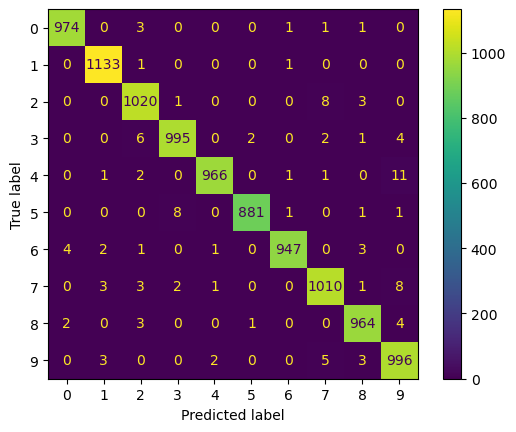

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(10)),
                                display_labels=np.arange(10))
fig = disp.plot(ax=None).figure_
plt.show()

Por fim, o modelo final seria avaliado em um conjunto de teste (que não está disponível no exemplo apresentado). **Vale ressaltar que o conjunto de teste não deve ser utilizado para refinar o modelo! Ele deve ser utilizado apenas para uma avaliação final do modelo.**

## Parte 2 - Classificação com o DermaMNIST

Vamos retomar a classificação do dataset de imagens dermatoscópicas de lesões de pele comuns, utilizado no Exercício 02. Desta vez, ao invés de extrair os atributos "artesanalmente" e classificar com o KNN, utilizaremos CNNs para realizar os dois processos simultaneamente (extração de atributos + classificação).

**Dataset**

O dataset consiste em 600 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 300 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 300 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe), um conjunto de validação com 100 imagens (50 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe). As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

### Exercício 2.1

Com base no exemplo apresentado e nos materiais de apoio disponibilizados, treine uma CNN para classificar as lesões de pele. Considere as recomendações abaixo:

- Considere aplicar [transformações](https://pytorch.org/vision/stable/transforms.html) durante a leitura dos dados, seja para normalizá-los ou realizar aumentação de dados.
- Lembre-se de sempre checar os dados!
- Você pode definir sua própria rede ou utilizar modelos de classificação disponibilizados pelo PyTorch (como a [ResNet](https://pytorch.org/vision/stable/models/resnet.html) ou a [EfficientNet](https://pytorch.org/vision/stable/models/efficientnet.html)). Caso utilize modelos disponibilizados, tome cuidado com as entradas e saídas da rede, talvez seja necessário realizar algumas modificações (como no exemplo apresentado). Considere também a utilização de modelos pré-treinados, eles apresentam resultados melhores do que modelos inicializados com pesos randômicos?
- Note que, no exemplo apresentado, os checkpoints da rede e os logs do PyTorch Lightning ficam salvos no ambiente de execução do Colab. Tome cuidado para não acabar perdendo experimentos! Você pode alterar o local em que esses arquivos são salvos para que sejam armazenados no seu Drive ou ainda salvar manualmente os arquivos que julgar importantes.
- Tente modificar os hiperparâmetros para obter melhores resultados de validação.
- Verifique os resultados do modelo: visualize algumas saídas da rede e obtenha métricas de classificação (acurácia, precisão, revocação e F1-score), além de imprimir a matriz de confusão.
- Idealmente, você deve avaliar apenas o modelo final no conjunto de teste.

Comente os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas. Compare também os resultados obtidos através da CNN com os resultados obtidos através do KNN no Exercício 02.

#### Criando dataset

In [ ]:
train_dataset_base = DermaMNIST(
    split="train",
    download=True
)

test_dataset_base = DermaMNIST(
    split="test",
    download=True
)

train_indices_0 = train_dataset_base.labels == 1
train_indices_1 = train_dataset_base.labels == 4

train_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][:200]
train_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][:200]
train_imgs = np.vstack([train_imgs_0, train_imgs_1])

val_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][200:250]
val_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][200:250]
val_imgs = np.vstack([val_imgs_0, val_imgs_1])


test_indices_0 = test_dataset_base.labels == 1
test_indices_1 = test_dataset_base.labels == 4

test_imgs_0 = test_dataset_base.imgs[test_indices_0.flatten(), :, :, :][:50]
test_imgs_1 = test_dataset_base.imgs[test_indices_1.flatten(), :, :, :][:50]
test_imgs = np.vstack([test_imgs_0, test_imgs_1])


train_labels = np.zeros(400)
train_labels[200:].fill(1)

val_labels = np.zeros(100)
val_labels[50:].fill(1)

test_labels = np.zeros(100)
test_labels[50:].fill(1)

train_dataset = TensorDataset(torch.tensor(train_imgs), torch.tensor(train_labels))
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

val_dataset = TensorDataset(torch.tensor(val_imgs), torch.tensor(val_labels))
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=0)

test_dataset = TensorDataset(torch.tensor(test_imgs), torch.tensor(test_labels))
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=0)

In [19]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, imgs, labels, transform=None):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.imgs)
        
    def __getitem__(self, idx):
        img = self.imgs[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

#### Normalização e Aumentação do dataset

##### Identificando a média e desvio padrão do dataset para normalizá-lo

In [20]:
from torchvision.transforms import v2

transform_tmp = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])
dataset_tmp = CustomDataset(train_imgs, train_labels, transform=transform_tmp)
dataloader_tmp = DataLoader(dataset_tmp, batch_size=32, shuffle=True, num_workers=0)

soma_canais = torch.tensor([0.0, 0.0, 0.0])
soma_quadrados_canais = torch.tensor([0.0, 0.0, 0.0])
num_batches = 0
for img, _ in dataloader_tmp:
        soma_canais += torch.mean(img, dim=[0, 2, 3])
        soma_quadrados_canais += torch.mean(img ** 2, dim=[0, 2, 3])        
        num_batches += 1

media = soma_canais / num_batches
std = torch.sqrt((soma_quadrados_canais / num_batches) - (media ** 2))

##### Definindo a transformação do dataset

In [ ]:
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=media, std=std)
])

train_dataset = CustomDataset(train_imgs, train_labels, transform=train_transforms)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)


val_test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=media, std=std)
])

val_dataset = CustomDataset(val_imgs, val_labels, transform=val_test_transforms)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=0)
test_dataset = CustomDataset(test_imgs, test_labels, transform=val_test_transforms)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=0)

#### Checando os dados

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.1759205..2.1398876].


torch.Size([32, 3, 224, 224])


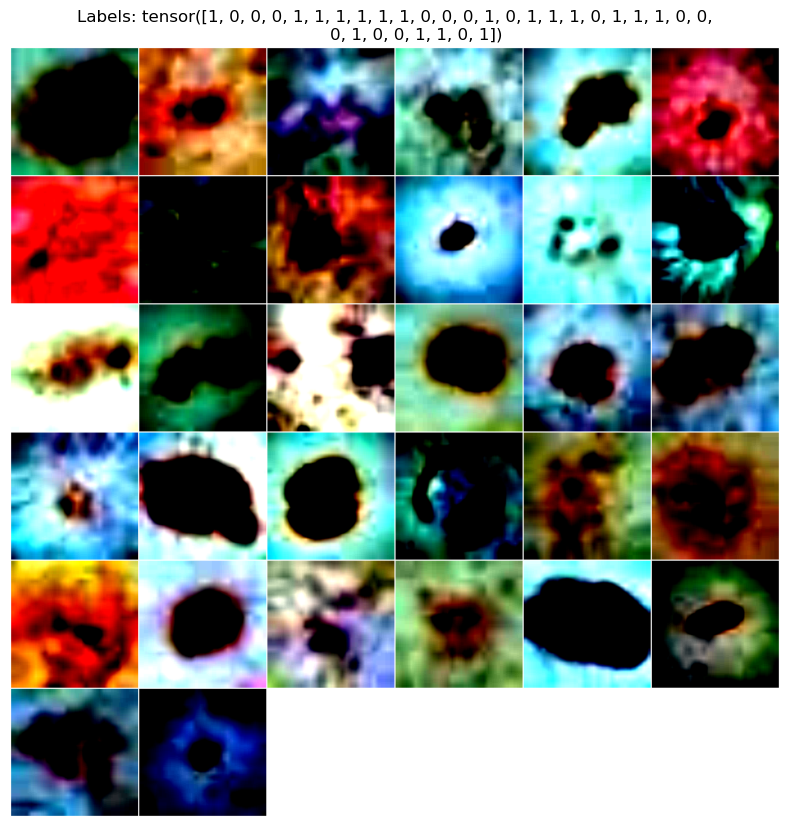

In [22]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
img_batch, label_batch = next(iter(train_dataloader))

print(img_batch.shape)

img_grid = make_grid(img_batch, nrow = 6, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1,2,0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()


As imagens do batch de treinamento estão agora com cores distorcidas (escuras e psicodélicas); isso ocorre porque agora a imagem possui valores fora do intervalo [0,1]. Mas essa prática de normalização das bandas das imagens do dataset é bem-vinda. Então não se assuste. 

Testes com ResNet18 c/ fine tunning e inicializada com pesos randômicos

###### ResNet18 com fine tunning

Arquitetura da Rede Neural ResNet18 c/ fine tunning

In [ ]:
import sys
import multiprocessing as mp
import torch

hparams = {
    "experiment_name": "ClassificadorPele-FineTuned",
    "max_epochs": 70,
    "batch_size": 32, # Ajustado para 32 para manter consistência com o que você fez antes
    "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),
    "nout": 2,  
    "nin": 3,
    "lr": 1e-4,
    "wd": 1e-5,
    "cpu": False,
}

cnn_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")
cnn_model.to(device)

Dispositivo utilizado: cuda:0


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
class ClassificadorDePeleDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = train_dataset
        self.val = val_dataset

    def train_dataloader(self):
        return torch.utils.data.DataLoader(self.train,
                                           batch_size=self.hparams.batch_size,
                                           num_workers=self.hparams.nworkers,
                                           shuffle=True,
                                           persistent_workers=True if self.hparams.nworkers > 0 else False,
                                           pin_memory=True)

    def val_dataloader(self):
        return torch.utils.data.DataLoader(self.val,
                                           batch_size=self.hparams.batch_size,
                                           num_workers=self.hparams.nworkers,
                                           shuffle=False,
                                           persistent_workers=True if self.hparams.nworkers > 0 else False,
                                           pin_memory=True)

In [ ]:
import torch.nn.functional as F
from torchvision import models
from torch import nn, optim
import pytorch_lightning as pl
from torchmetrics import Accuracy

class ClassificadorDePele(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)
        
    def forward(self, x):
        return self.model(x)
    
    def classification_step(self, mode, batch):
        x, y = batch
        logits = self.forward(x)
        loss = self.loss(logits, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            preds = torch.argmax(logits, dim=1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)
        return optimizer

Treinando a CNN

In [ ]:
import torchinfo
import os
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping # Nova importação!

debug = False  # Turn this True to test the code with a quick run


model = ClassificadorDePele(hparams)
data = ClassificadorDePeleDataModule(hparams)

os.makedirs("logs", exist_ok=True)

checkpoint_callback = ModelCheckpoint(
    dirpath="logs",  
    filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
    monitor="val_acc",
    mode="max"
)

early_stop_callback = EarlyStopping(
    monitor="val_acc",
    min_delta=0.00,
    patience=16,
    verbose=True,
    mode="max"
)

trainer = pl.Trainer(
    max_epochs=hparams["max_epochs"], # Aumentamos o limite, mas o Early Stopping deve parar antes
    fast_dev_run=debug,
    callbacks=[checkpoint_callback, early_stop_callback], # Lista com os dois callbacks
    log_every_n_steps=1
)

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/visionary/miniconda3/envs/env/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/visionary/Brendon/LeticiaRittner/pi05/logs exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Hyperparameters:

experiment_name: ClassificadorPele-FineTuned
max_epochs: 70
batch_size: 32
nworkers: 8
nout: 2
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/visionary/miniconda3/envs/env/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Metric val_acc improved. New best score: 0.780
Metric val_acc improved by 0.140 >= min_delta = 0.0. New best score: 0.920
Metric val_acc improved by 0.010 >= min_delta = 0.0. New best score: 0.930
Metric val_acc improved by 0.010 >= min_delta = 0.0. New best score: 0.940
Metric val_acc improved by 0.010 >= min_delta = 0.0. New best score: 0.950
Metric val_acc improved by 0.010 >= min_delta = 0.0. New best score: 0.960
Monitored metric val_acc did not improve in the last 16 records. Best score: 0.960. Signaling Trainer to stop.


Acurácia, Precisão, Recall e F1-score

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

model.eval()
model.to(device)

y_true = []
y_pred = []
images_to_show = []
labels_to_show = []
preds_to_show = []

# Desativar cálculo de gradientes
with torch.no_grad():
    for imgs, labels in test_dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Fazer as predições
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        # Salvar os resultados reais e preditos
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        # Guardar as primeiras 6 imagens
        if len(images_to_show) < 6:
            for i in range(min(6, len(imgs))):
                images_to_show.append(imgs[i].cpu())
                labels_to_show.append(labels[i].cpu().item())
                preds_to_show.append(preds[i].cpu().item())


print(f"Acurácia:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precisão:  {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Revocação: {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred, average='macro'):.4f}")

Acurácia:  0.9200
Precisão:  0.9227
Revocação: 0.9200
F1-Score:  0.9199


Matriz de Confusão

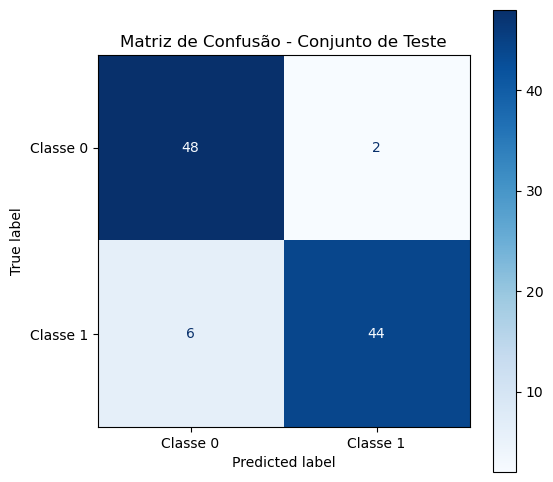

In [28]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Matriz de Confusão - Conjunto de Teste")
plt.show()

Testando o modelo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7987915..1.3054029].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.786176..2.6442614].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.9360776..0.57367414].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2351637..1.2107781].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0111785..1.2373241].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.5569823..1.423146].


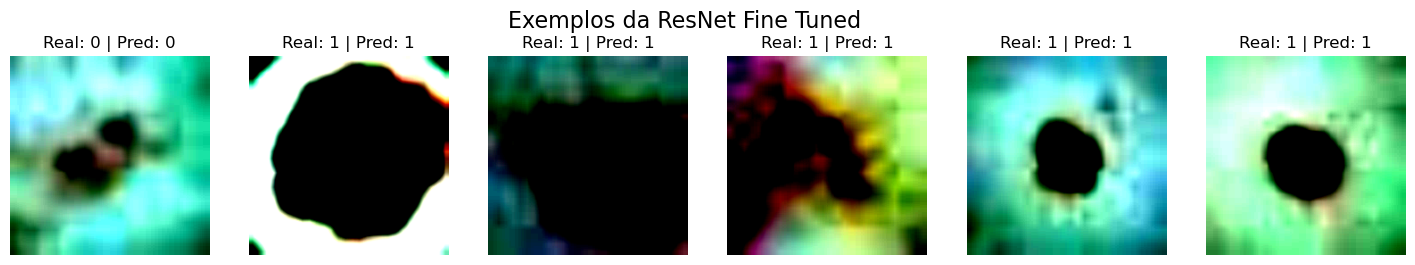

In [ ]:
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i in range(6):
    img = images_to_show[i].permute(1, 2, 0).numpy()
    
    axes[i].imshow(img)
    axes[i].set_title(f"Real: {labels_to_show[i]} | Pred: {preds_to_show[i]}")
    axes[i].axis('off')

plt.suptitle("Exemplos da ResNet Fine Tuned", fontsize=16)
plt.show()

###### ResNet18 com pesos randômicos

In [ ]:
hparams = {
    "experiment_name": "ClassificadorPele-ComPesosRandomicos",
    "max_epochs": 70,
    "batch_size": 32,
    "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),
    "nout": 2,  
    "nin": 3,
    "lr": 1e-4,
    "wd": 1e-5,
    "cpu": False,
}

In [ ]:
cnn_model = models.resnet18(weights=None)

num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")
cnn_model.to(device)

Dispositivo utilizado: cuda:0


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
class ClassificadorDePeleDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = train_dataset
        self.val = val_dataset

    def train_dataloader(self):
        return torch.utils.data.DataLoader(self.train,
                                           batch_size=self.hparams.batch_size,
                                           num_workers=self.hparams.nworkers,
                                           shuffle=True,
                                           persistent_workers=True if self.hparams.nworkers > 0 else False,
                                           pin_memory=True)

    def val_dataloader(self):
        return torch.utils.data.DataLoader(self.val,
                                           batch_size=self.hparams.batch_size,
                                           num_workers=self.hparams.nworkers,
                                           shuffle=False,
                                           persistent_workers=True if self.hparams.nworkers > 0 else False,
                                           pin_memory=True)

In [ ]:
import torch.nn.functional as F
from torchvision import models
from torch import nn, optim
import pytorch_lightning as pl
from torchmetrics import Accuracy

class ClassificadorDePele(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

    def forward(self, x):
        return self.model(x) 

    def classification_step(self, mode, batch):
        x, y = batch
        logits = self.forward(x)
        loss = self.loss(logits, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            preds = torch.argmax(logits, dim=1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)
        return optimizer

Treinando a CNN

In [ ]:
import torchinfo
import os
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping # Nova importação!

debug = False  # Turn this True to test the code with a quick run

model = ClassificadorDePele(hparams)
data = ClassificadorDePeleDataModule(hparams)

os.makedirs("logs", exist_ok=True)

checkpoint_callback = ModelCheckpoint(
    dirpath="logs",  
    filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
    monitor="val_acc",
    mode="max"
)

early_stop_callback = EarlyStopping(
    monitor="val_acc",
    min_delta=0.00,
    patience=16,
    verbose=True,
    mode="max"
)


trainer = pl.Trainer(
    max_epochs=hparams["max_epochs"],
    fast_dev_run=debug,
    callbacks=[checkpoint_callback, early_stop_callback],
    log_every_n_steps=1
)

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/visionary/miniconda3/envs/env/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/visionary/Brendon/LeticiaRittner/pi05/logs exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Hyperparameters:

experiment_name: ClassificadorPele-ComPesosRandomicos
max_epochs: 70
batch_size: 32
nworkers: 8
nout: 2
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/visionary/miniconda3/envs/env/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Metric val_acc improved. New best score: 0.740
Metric val_acc improved by 0.070 >= min_delta = 0.0. New best score: 0.810
Metric val_acc improved by 0.030 >= min_delta = 0.0. New best score: 0.840
Metric val_acc improved by 0.020 >= min_delta = 0.0. New best score: 0.860
Metric val_acc improved by 0.050 >= min_delta = 0.0. New best score: 0.910
Monitored metric val_acc did not improve in the last 16 records. Best score: 0.910. Signaling Trainer to stop.


Acurácia, Precisão, Recall e F1-score

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

model.eval()
model.to(device)

y_true = []
y_pred = []
images_to_show = []
labels_to_show = []
preds_to_show = []

with torch.no_grad():
    for imgs, labels in test_dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Fazer as predições
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        # Salvar os resultados reais e preditos
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        # Guardar as primeiras 6 imagens
        if len(images_to_show) < 6:
            for i in range(min(6, len(imgs))):
                images_to_show.append(imgs[i].cpu())
                labels_to_show.append(labels[i].cpu().item())
                preds_to_show.append(preds[i].cpu().item())


print(f"Acurácia:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precisão:  {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Revocação: {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred, average='macro'):.4f}")

Acurácia:  0.8800
Precisão:  0.8806
Revocação: 0.8800
F1-Score:  0.8800


Matriz de Confusão

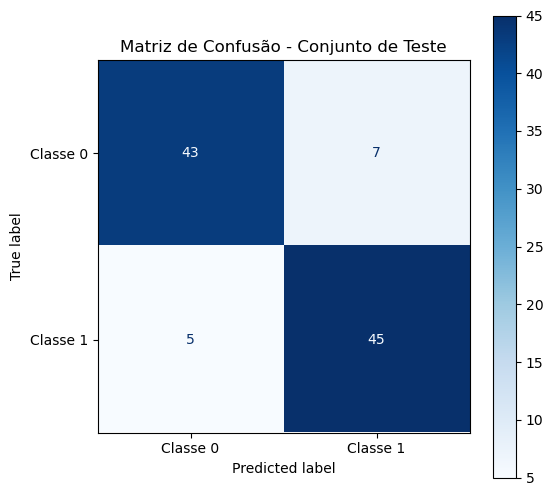

In [36]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Matriz de Confusão - Conjunto de Teste")
plt.show()

Testando o modelo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.2271986..0.3082143].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9573758..0.3082143].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.5569823..1.8146625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0260186..1.3539038].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7016538..0.8688944].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2402003..1.0899699].


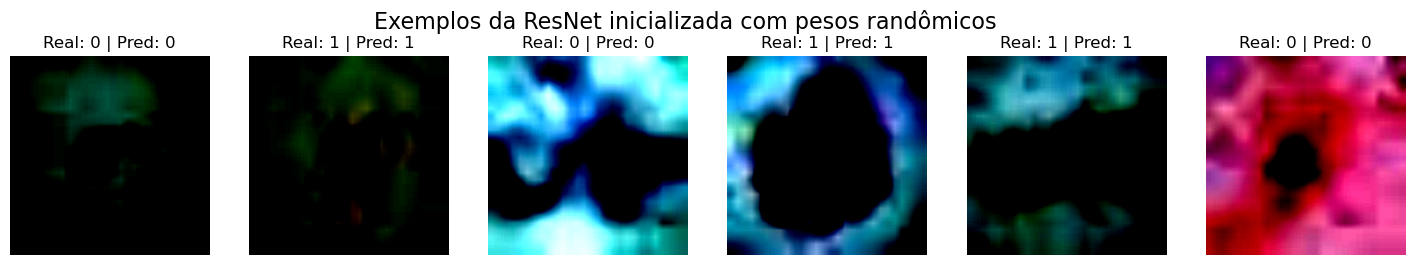

In [ ]:
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i in range(6):
    img = images_to_show[i].permute(1, 2, 0).numpy()
    
    axes[i].imshow(img)
    axes[i].set_title(f"Real: {labels_to_show[i]} | Pred: {preds_to_show[i]}")
    axes[i].axis('off')

plt.suptitle("Exemplos da ResNet inicializada com pesos randômicos", fontsize=16)
plt.show()

**RESPOSTA:**

Percebe-se pelo exercício que entre a ResNet18 com pesos-padrão, e a ResNet18 com pesos randômicos, a ResNet18 com pesos-padrão produziu melhores resultados; isso se percebe nas métricas de avaliação. Nas quatro métricas, a rede com peso padrão produziu no mínimo 90% de score. Isso é um valor bacana. Mesmo tendo que fazer um upscale nas imagens do dataset, pois para ficar páreo à proposta de datasets que a ResNet foi desenvolvida para atender.

Resposta sobre o comparativo do KNN do Exercício 2.

O KNN produziu: acc_test:0.800, prec_test:0.768, rec_test:0.860, f1_test:0.811. Isso é muito interessante, pois enquanto a CNN "olha a imagem", o KNN utilizando métricas estatísticas sumarizadoras e outras descritoras do histograma ('Média', 'Variância', 'Skewness', 'Kurtosis', '1%_percentil', '10%_percentil', '50%_percentil', '90%_percentil', '99%_percentil') produziu resultados bacanas.

## Parte 3 - Classificação com o DermaMNIST original (opcional para EA979)

### Exercício 3.1

Treine novamente o modelo final do exercício anterior, mas dessa vez utilize o conjunto original de dados do DermaMNIST (train_dataset_base, test_dataset_base).

**Note que o conjunto original de dados possui 7 classes distintas, mas estamos interessados apenas em duas classes: casos de carcinoma basocelular (label 1) e melanoma (label 4).** Portanto, você deve filtrar e organizar os dados para que eles sejam utilizados na classificação.

Verifique a quantidade de amostras de cada classe de interesse nos conjuntos de treino, validação e teste. Você deve notar que as duas classes estão desbalanceadas. Busque alternativas para lidar com esse desbalanceamento. Após aplicar as modificações os resultados da rede melhoraram?

Não se esqueça de comentar sobre os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas.

In [38]:
# Filtrando apenas as classes de interesse do DermaMNIST original:

train_indices_0 = (train_dataset_base.labels == 1).flatten()
train_indices_1 = (train_dataset_base.labels == 4).flatten()

val_indices_0   = (train_dataset_base.labels == 1).flatten()
val_indices_1   = (train_dataset_base.labels == 4).flatten()

test_indices_0  = (test_dataset_base.labels == 1).flatten()
test_indices_1  = (test_dataset_base.labels == 4).flatten()

# Verificando a quantidade total de amostras disponíveis por classe
print("Treino+Val (split='train' do DermaMNIST)")
print(f"Carcinoma Basocelular (label 1): {train_indices_0.sum()} amostras")
print(f"Melanoma (label 4): {train_indices_1.sum()} amostras")

print("\nTeste (split='test' do DermaMNIST)")
print(f"Carcinoma Basocelular (label 1): {test_indices_0.sum()} amostras")
print(f"Melanoma (label 4): {test_indices_1.sum()} amostras")

Treino+Val (split='train' do DermaMNIST)
Carcinoma Basocelular (label 1): 359 amostras
Melanoma (label 4): 779 amostras

Teste (split='test' do DermaMNIST)
Carcinoma Basocelular (label 1): 103 amostras
Melanoma (label 4): 223 amostras


In [39]:
# Utilizaram-se TODAS as amostras disponíveis de cada classe, separando 80% para treino e 20% para validação.

all_imgs_0 = train_dataset_base.imgs[train_indices_0]
all_imgs_1 = train_dataset_base.imgs[train_indices_1]

n0 = len(all_imgs_0)
n1 = len(all_imgs_1)

split0 = int(0.8 * n0)
split1 = int(0.8 * n1)

train_imgs_0, val_imgs_0 = all_imgs_0[:split0], all_imgs_0[split0:]
train_imgs_1, val_imgs_1 = all_imgs_1[:split1], all_imgs_1[split1:]

train_imgs = np.vstack([train_imgs_0, train_imgs_1])
val_imgs   = np.vstack([val_imgs_0,   val_imgs_1])


test_imgs_0 = test_dataset_base.imgs[test_indices_0]
test_imgs_1 = test_dataset_base.imgs[test_indices_1]
test_imgs   = np.vstack([test_imgs_0, test_imgs_1])


train_labels = np.array([0] * len(train_imgs_0) + [1] * len(train_imgs_1))
val_labels   = np.array([0] * len(val_imgs_0)   + [1] * len(val_imgs_1))
test_labels  = np.array([0] * len(test_imgs_0)  + [1] * len(test_imgs_1))

print("Amostras após separação")
print(f"Treino: Classe 0: {len(train_imgs_0)} | Classe 1: {len(train_imgs_1)}")
print(f"Val: Classe 0: {len(val_imgs_0)}   | Classe 1: {len(val_imgs_1)}")
print(f"Teste: Classe 0: {len(test_imgs_0)}  | Classe 1: {len(test_imgs_1)}")

Amostras após separação
Treino: Classe 0: 287 | Classe 1: 623
Val: Classe 0: 72   | Classe 1: 156
Teste: Classe 0: 103  | Classe 1: 223


Obtendo estatísticas para normalização do dataset

In [40]:
from torchvision.transforms import v2

transform_tmp = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])
dataset_tmp = CustomDataset(train_imgs, train_labels, transform=transform_tmp)
dataloader_tmp = DataLoader(dataset_tmp, batch_size=32, shuffle=True, num_workers=0)

soma_canais = torch.tensor([0.0, 0.0, 0.0])
soma_quadrados_canais = torch.tensor([0.0, 0.0, 0.0])
num_batches = 0
for img, _ in dataloader_tmp:
        soma_canais += torch.mean(img, dim=[0, 2, 3])
        soma_quadrados_canais += torch.mean(img ** 2, dim=[0, 2, 3])        
        num_batches += 1

media = soma_canais / num_batches
std = torch.sqrt((soma_quadrados_canais / num_batches) - (media ** 2))

print(f"Média: {media}")
print(f"Std:   {std}")

Média: tensor([0.7237, 0.5617, 0.5877])
Std:   tensor([0.1369, 0.1543, 0.1697])


In [41]:
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=15),           # Aumenta variedade na classe minoritária
    v2.ColorJitter(brightness=0.2, contrast=0.2),  # idem
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=media, std=std)
])

val_test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=media, std=std)
])

train_dataset = CustomDataset(train_imgs, train_labels, transform=train_transforms)
val_dataset   = CustomDataset(val_imgs,   val_labels,   transform=val_test_transforms)
test_dataset  = CustomDataset(test_imgs,  test_labels,  transform=val_test_transforms)

In [ ]:
from torch.utils.data import WeightedRandomSampler

# Classes com menos amostras recebem peso maior, sendo sorteadas mais frequentemente
class_counts = np.bincount(train_labels.astype(int))
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels.astype(int)]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(train_labels),
    replacement=True   # Permite reamostrar a classe minoritária
)

print(f"Contagem por classe no treino: {class_counts}")
print(f"Pesos por classe: {class_weights}")

Contagem por classe no treino: [287 623]
Pesos por classe: [0.00348432 0.00160514]


In [ ]:
import sys
import multiprocessing as mp
import torch
from torchvision import models
from torch import nn

hparams = {
    "experiment_name": "ClassificadorPele-Desbalanceado",
    "max_epochs": 70,
    "batch_size": 32,
    "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),
    "nout": 2,
    "nin": 3,
    "lr": 1e-4,
    "wd": 1e-5,
    "cpu": False,
}

cnn_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")
cnn_model.to(device)

class_counts = np.bincount(train_labels.astype(int))
loss_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
print(f"Pesos no loss: {loss_weights}")

Dispositivo utilizado: cuda:0
Pesos no loss: tensor([0.0035, 0.0016], device='cuda:0')


In [44]:
class ClassificadorDePeleDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = train_dataset
        self.val   = val_dataset

    def train_dataloader(self):
        return torch.utils.data.DataLoader(self.train,
                                           batch_size=self.hparams.batch_size,
                                           num_workers=self.hparams.nworkers,
                                           sampler=sampler,         # substitui shuffle=True
                                           persistent_workers=True if self.hparams.nworkers > 0 else False,
                                           pin_memory=True)

    def val_dataloader(self):
        return torch.utils.data.DataLoader(self.val,
                                           batch_size=self.hparams.batch_size,
                                           num_workers=self.hparams.nworkers,
                                           shuffle=False,
                                           persistent_workers=True if self.hparams.nworkers > 0 else False,
                                           pin_memory=True)

In [ ]:
import torch.nn.functional as F
from torchvision import models
from torch import nn, optim
import pytorch_lightning as pl
from torchmetrics import Accuracy

class ClassificadorDePele(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)
        self.model = cnn_model
        # Loss ponderado: penaliza mais os erro na classe minoritária/melanoma
        self.loss = nn.CrossEntropyLoss(weight=loss_weights)
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

    def forward(self, x):
        return self.model(x)

    def classification_step(self, mode, batch):
        x, y = batch
        logits = self.forward(x)
        loss = self.loss(logits, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            preds = torch.argmax(logits, dim=1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)
        return optimizer

Treinamento

In [46]:
import torchinfo
import os
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

debug = False

model = ClassificadorDePele(hparams)
data  = ClassificadorDePeleDataModule(hparams)

os.makedirs("logs", exist_ok=True)

checkpoint_callback = ModelCheckpoint(
    dirpath="logs",
    filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
    monitor="val_acc",
    mode="max"
)

early_stop_callback = EarlyStopping(
    monitor="val_acc",
    min_delta=0.00,
    patience=16,
    verbose=True,
    mode="max"
)

trainer = pl.Trainer(
    max_epochs=hparams["max_epochs"],
    fast_dev_run=debug,
    callbacks=[checkpoint_callback, early_stop_callback],
    log_every_n_steps=1
)

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/visionary/miniconda3/envs/env/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/visionary/Brendon/LeticiaRittner/pi05/logs exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Hyperparameters:

experiment_name: ClassificadorPele-Desbalanceado
max_epochs: 70
batch_size: 32
nworkers: 8
nout: 2
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/visionary/miniconda3/envs/env/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Metric val_acc improved. New best score: 0.904
Metric val_acc improved by 0.009 >= min_delta = 0.0. New best score: 0.912
Metric val_acc improved by 0.026 >= min_delta = 0.0. New best score: 0.939
Metric val_acc improved by 0.004 >= min_delta = 0.0. New best score: 0.943
Monitored metric val_acc did not improve in the last 16 records. Best score: 0.943. Signaling Trainer to stop.


Obtendo acurácia, precisão, recall e f1-score

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

model.eval()
model.to(device)

y_true = []
y_pred = []
images_to_show = []
labels_to_show = []
preds_to_show = []


with torch.no_grad():
    for imgs, labels in test_dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Fazer as predições
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        # Salvar os resultados reais e preditos
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        # Guardar as primeiras 6 imagens
        if len(images_to_show) < 6:
            for i in range(min(6, len(imgs))):
                images_to_show.append(imgs[i].cpu())
                labels_to_show.append(labels[i].cpu().item())
                preds_to_show.append(preds[i].cpu().item())


print(f"Acurácia:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precisão:  {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Recall: {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred, average='macro'):.4f}")

Acurácia:  0.9100
Precisão:  0.9141
Recall: 0.9100
F1-Score:  0.9098


Matriz de Confusão

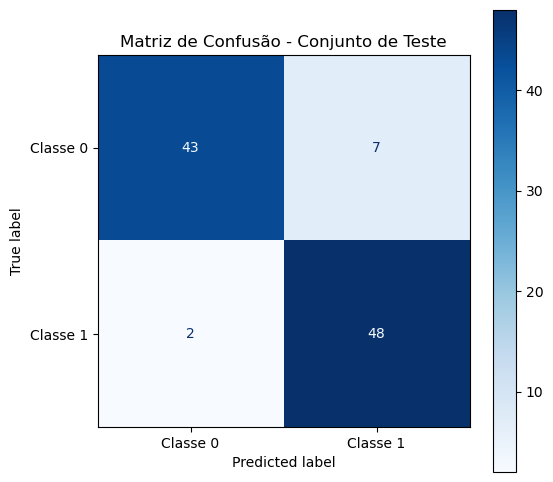

In [48]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Matriz de Confusão - Conjunto de Teste")
plt.show()

Testando o modelo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.0966287..1.9893793].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7987915..1.3054029].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94988954..1.423146].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.5569823..1.8146625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6382408..1.6449093].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.5746703..1.5696552].


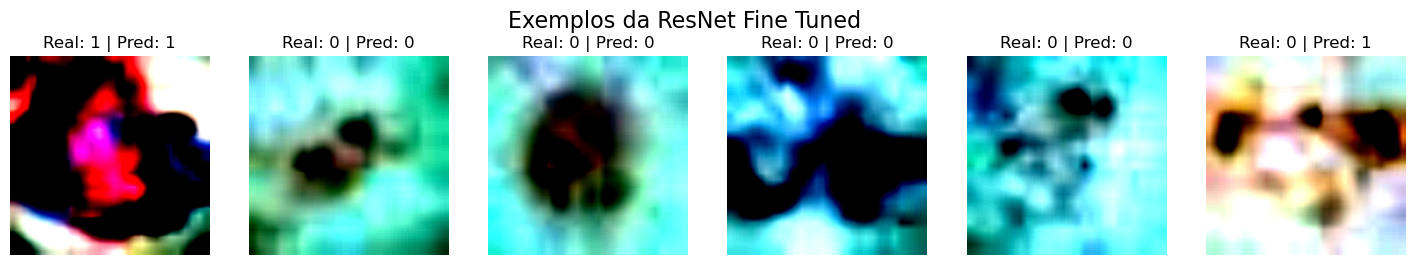

In [ ]:
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i in range(6):
    img = images_to_show[i].permute(1, 2, 0).numpy()
    
    axes[i].imshow(img)
    axes[i].set_title(f"Real: {labels_to_show[i]} | Pred: {preds_to_show[i]}")
    axes[i].axis('off')

plt.suptitle("Exemplos da ResNet Fine Tuned", fontsize=16)
plt.show()